In [1]:
#Some Helper functions referenced from https://github.com/switchablenorms/CelebAMask-HQ
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class unetConv2(nn.Module):
    def __init__(self, in_size, out_size, is_batchnorm):
        super(unetConv2, self).__init__()

        #num_test_groups = 8
        if is_batchnorm:
            self.conv1 = nn.Sequential(
                nn.Conv2d(in_size, out_size, 3, 1, 1),
                nn.BatchNorm2d(out_size),
                #nn.GroupNorm(num_test_groups, out_size),
                nn.ReLU(),
            )
            self.conv2 = nn.Sequential(
                nn.Conv2d(out_size, out_size, 3, 1, 1),
                nn.BatchNorm2d(out_size),
                #nn.GroupNorm(num_test_groups, out_size),
                nn.ReLU(),
            )
        else:
            self.conv1 = nn.Sequential(nn.Conv2d(in_size, out_size, 3, 1, 1), nn.ReLU())
            self.conv2 = nn.Sequential(
                nn.Conv2d(out_size, out_size, 3, 1, 1), nn.ReLU()
            )

    def forward(self, inputs):
        outputs = self.conv1(inputs)
        #print (outputs.shape)
        outputs = self.conv2(outputs)
        #print (outputs.shape)
        return outputs


class unetUp(nn.Module):
    def __init__(self, in_size, out_size, is_deconv, is_batchnorm):
        super(unetUp, self).__init__()
        self.conv = unetConv2(in_size, out_size, is_batchnorm)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.reduce = nn.Conv2d(in_size, out_size, 1)


    def forward(self, inputs1, inputs2):
        outputs2 = self.up(inputs2)
        outputs2 = self.reduce(outputs2)

        offset = outputs2.size()[2] - inputs1.size()[2]
        padding = 2 * [offset // 2, offset // 2]
        outputs1 = F.pad(inputs1, padding)

        return self.conv(torch.cat([outputs1, outputs2], 1))

In [2]:
class unet(nn.Module):
    def __init__(
        self,
        feature_scale=4,
        n_classes=19,
        is_deconv=True,
        in_channels=3,
        is_batchnorm=True,
    ):
        super(unet, self).__init__()
        self.is_deconv = is_deconv
        self.in_channels = in_channels
        self.is_batchnorm = is_batchnorm
        self.feature_scale = feature_scale

        filters = [64, 128, 256, 512, 1024]
        #filters = [32, 64, 128, 256, 512]
        #filters = [56, 112, 224, 448, 896]
        filters = [int(x / self.feature_scale) for x in filters]

        # downsampling
        self.conv1 = unetConv2(self.in_channels, filters[0], self.is_batchnorm)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = unetConv2(filters[0], filters[1], self.is_batchnorm)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = unetConv2(filters[1], filters[2], self.is_batchnorm)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = unetConv2(filters[2], filters[3], self.is_batchnorm)
        self.maxpool4 = nn.MaxPool2d(kernel_size=2)

        self.center = unetConv2(filters[3], filters[4], self.is_batchnorm)

        self.dropout = nn.Dropout2d(p=0.2)

        # upsampling
        self.up_concat4 = unetUp(filters[4], filters[3], self.is_deconv, self.is_batchnorm)
        self.up_concat3 = unetUp(filters[3], filters[2], self.is_deconv, self.is_batchnorm)
        self.up_concat2 = unetUp(filters[2], filters[1], self.is_deconv, self.is_batchnorm)
        self.up_concat1 = unetUp(filters[1], filters[0], self.is_deconv, self.is_batchnorm)

        # final conv (without any concat)
        self.final = nn.Conv2d(filters[0], n_classes, 1)

    def forward(self, inputs):
        conv1 = self.conv1(inputs)
        maxpool1 = self.maxpool1(conv1)

        conv2 = self.conv2(maxpool1)
        maxpool2 = self.maxpool2(conv2)

        conv3 = self.conv3(maxpool2)
        maxpool3 = self.maxpool3(conv3)

        conv4 = self.conv4(maxpool3)
        maxpool4 = self.maxpool4(conv4)

        center = self.center(maxpool4)
        center = self.dropout(center)
        up4 = self.up_concat4(conv4, center)
        up3 = self.up_concat3(conv3, up4)
        up2 = self.up_concat2(conv2, up3)
        up1 = self.up_concat1(conv1, up2)

        final = self.final(up1)

        return final

In [3]:
import os
import torch
import numpy as np
from torch.autograd import Variable
import torch.nn.functional as F


#Referenced from https://medium.com/data-scientists-diary/implementation-of-dice-loss-vision-pytorch-7eef1e438f68
def multiclass_dice_loss(pred, target, smooth=1):
    """
    Computes Dice Loss for multi-class segmentation.
    Args:
        pred: Tensor of predictions (batch_size, C, H, W).
        target: One-hot encoded ground truth (batch_size, C, H, W).
        smooth: Smoothing factor.
    Returns:
        Scalar Dice Loss.
    """
    pred = F.softmax(pred, dim=1)  # Convert logits to probabilities
    num_classes = pred.shape[1]  # Number of classes (C)
    dice = 0  # Initialize Dice loss accumulator
    
    for c in range(num_classes):  # Loop through each class
        pred_c = pred[:, c]  # Predictions for class c
        target_c = target[:, c]  # Ground truth for class c
        
        intersection = (pred_c * target_c).sum(dim=(1, 2))  # Element-wise multiplication
        union = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2))  # Sum of all pixels
        
        dice += (2. * intersection + smooth) / (union + smooth)  # Per-class Dice score

    return 1 - dice.mean() / num_classes  # Average Dice Loss across classes


# -----------------------------------------------------------
# Custom 2D Cross Entropy Loss for segmentation
# Handles size mismatch via interpolation
# Ignores label index 250
# -----------------------------------------------------------
def cross_entropy2d(input, target, weight=None, size_average=True):
    n, c, h, w = input.size()
    nt, ht, wt = target.size()

    # Resize input if needed
    if h != ht or w != wt:
        input = F.interpolate(input, size=(ht, wt),
                              mode="bilinear", align_corners=True)

    # Flatten for cross entropy
    input = input.transpose(1, 2).transpose(2, 3).contiguous().view(-1, c)
    target = target.view(-1)

    loss = F.cross_entropy(
        input,
        target,
        weight=weight,
        reduction='mean',
        ignore_index=250
    )
    return loss

In [4]:
import torch
import torchvision.datasets as dsets
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import os
import random

# Fixed crop and resize to 448x448 and 512x512 - Discarded in favour of MultiScaleRandomCrop
class RandomCropResize:
    def __init__(self, crop_size=448, final_size=512):
        self.crop_size = crop_size
        self.final_size = final_size

    def __call__(self, img, mask):

        w, h = img.size

        if w == self.crop_size and h == self.crop_size:
            i, j = 0, 0
        else:
            i = random.randint(0, h - self.crop_size)
            j = random.randint(0, w - self.crop_size)

        img = TF.crop(img, i, j, self.crop_size, self.crop_size)
        mask = TF.crop(mask, i, j, self.crop_size, self.crop_size)

        img = TF.resize(img, (self.final_size, self.final_size), interpolation=Image.BILINEAR)
        mask = TF.resize(mask, (self.final_size, self.final_size), interpolation=Image.NEAREST)

        return img, mask

# Crops the image to random resolution and resizes back to 512x512
class MultiScaleRandomCrop:
    def __init__(self, min_size=380, max_size=512, final_size=512):
        self.min_size = min_size
        self.max_size = max_size
        self.final_size = final_size

    def __call__(self, img, mask):
        w, h = img.size
        
        # Chooses random crop size
        current_crop_size = random.randint(self.min_size, min(w, h, self.max_size))

        # Random crop location
        i = random.randint(0, h - current_crop_size)
        j = random.randint(0, w - current_crop_size)

        img = TF.crop(img, i, j, current_crop_size, current_crop_size)
        mask = TF.crop(mask, i, j, current_crop_size, current_crop_size)

        img = TF.resize(img, (self.final_size, self.final_size), interpolation=Image.BILINEAR)
        mask = TF.resize(mask, (self.final_size, self.final_size), interpolation=Image.NEAREST)

        return img, mask

class CelebAMaskHQ():
    def __init__(self, img_path, label_path, transform_img, transform_label, mode):
        self.img_path = img_path
        self.label_path = label_path
        self.transform_img = transform_img
        self.transform_label = transform_label
        self.train_dataset = []
        self.test_dataset = []
        self.mode = mode
        self.preprocess()
        #self.crop = RandomCropResize(448, 512)
        self.crop = MultiScaleRandomCrop(380, 512, 512)

        if mode == True:
            self.num_images = len(self.train_dataset)
        else:
            self.num_images = len(self.test_dataset)

    def preprocess(self):

        all_images = [f for f in os.listdir(self.img_path) if f.lower().endswith('.jpg')]

        for filename in all_images:
            file_id = os.path.splitext(filename)[0]
            
            img_path = os.path.join(self.img_path, filename)
            label_path = os.path.join(self.label_path, file_id + '.png')

            #print(img_path)
            #print(label_path)
            
            if os.path.exists(label_path):
                if self.mode == True:
                    self.train_dataset.append([img_path, label_path])
                else:
                    self.test_dataset.append([img_path, label_path])
            else:
                print(f"Warning: No label found for {img_path}")

        print(f"Finished preprocessing. Total loaded: {len(self.train_dataset if self.mode else self.test_dataset)}")

    def __getitem__(self, index):

        dataset = self.train_dataset if self.mode == True else self.test_dataset
        img_path, label_path = dataset[index]
        image = Image.open(img_path)
        label = Image.open(label_path)
        if self.mode: # Training mode
        # Random Rotation
        #    if random.random() > 0.5:
        #        angle = random.randint(-20, 20)
        #        image = TF.rotate(image, angle)
        #        label = TF.rotate(label, angle, interpolation=TF.InterpolationMode.NEAREST)

        # Random Horizontal Flip
            #if random.random() > 0.5:
            #    image = TF.hflip(image)
            #    label = TF.hflip(label)

            image, label = self.crop(image, label)
        return self.transform_img(image), self.transform_label(label)

    def __len__(self):
        """Return the number of images."""
        return self.num_images

class Data_Loader():
    def __init__(self, img_path, label_path, image_size, batch_size, mode):
        self.img_path = img_path
        self.label_path = label_path
        self.imsize = image_size
        self.batch = batch_size
        self.mode = mode

    def __len__(self):
        # Return the total number of images you have
        return len(self.image_filenames)

    def transform_img(self, resize, totensor, normalize, centercrop, colorjitter):
        options = []
        options.append(transforms.RandomApply([
            transforms.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, hue = 0.1)], p = 0.6))
        options.append(transforms.RandomGrayscale(p = 0.1))
        options.append(transforms.RandomApply([
                        transforms.RandomChoice([
                            transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)), 
                            transforms.RandomAdjustSharpness(sharpness_factor=2, p = 0.5) # Removed internal p
                        ])
                    ], p=0.3))
        #if centercrop:
        #    options.append(transforms.CenterCrop(160))
        if resize:
            options.append(transforms.Resize((self.imsize,self.imsize)))
        if totensor:
            options.append(transforms.ToTensor())
        if normalize:
            #options.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
            # The below values were computed based on training data samples - Mean and Standard Deviation
            # Code for calculating this is given at end of the notebook
            options.append(transforms.Normalize(mean=[0.5081, 0.4134, 0.3607],std=[0.3013, 0.2757, 0.2692]))
        transform = transforms.Compose(options)
        return transform

    def transform_label(self, resize, totensor, normalize, centercrop):
        options = []
        if centercrop:
            options.append(transforms.CenterCrop(160))
        if resize:
            options.append(transforms.Resize((self.imsize,self.imsize)))
        if totensor:
            options.append(transforms.ToTensor())
        if normalize:
            options.append(transforms.Normalize((0, 0, 0), (0, 0, 0)))
        transform = transforms.Compose(options)
        return transform

    def loader(self):
        transform_img = self.transform_img(True, True, True, False, True)
        transform_label = self.transform_label(True, True, False, False)
        dataset = CelebAMaskHQ(self.img_path, self.label_path, transform_img, transform_label, self.mode)

        loader = torch.utils.data.DataLoader(dataset=dataset,
                                             batch_size=self.batch,
                                             shuffle=True,
                                             num_workers=2,
                                             drop_last=False)
        return loader


In [8]:
import torch
import torch.nn as nn

def count_parameters(model):
    # Calculates total trainable params
    return sum(p.numel() for p in model.parameters())

def build_model(device, parallel=False, feature_scale=4, n_classes=19, lr=0.0005, beta1=0.5, beta2=0.999):
    # Initialization of model, parameter check and optimizer set up
    
    unet_model = unet(feature_scale=feature_scale, n_classes=n_classes, is_deconv=True).to(device)
    
    params = count_parameters(unet_model)
    print(f"Total Trainable Params: {params:,}")
    
    limit = 1821085
    if params <= limit:
        print(f"Safe: Under the {limit:,} limit.")
    else:
        print(f"Warning: You are {params - limit:,} over the limit!")

    if parallel and torch.cuda.device_count() > 1:
        unet_model = nn.DataParallel(unet_model)

    unet_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, unet_model.parameters()), 
        lr=lr, 
        betas=(beta1, beta2)
    )

    return unet_model, unet_optimizer

In [9]:
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./samples', exist_ok=True)
os.makedirs('/predicted_test_labels_newer', exist_ok=True)

In [10]:
data_loader = Data_Loader("/kaggle/input/datasets/sriharisridhar123/celeb-subset/train/images/", "/kaggle/input/datasets/sriharisridhar123/celeb-subset/train/masks/", 512, 8, True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
unet_model, unet_optimizer =  build_model(device)

Total Trainable Params: 1,813,795
Safe: Under the 1,821,085 limit.


In [11]:
import time
import datetime
import torch
import os
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Main training function - Trains the U-Net model
def train_model(model, train_loader, optimizer, total_epochs, save_path, device):
    model.to(device)
    start_time = time.time()
    #scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    scheduler = CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-5)

    total_step = len(train_loader) * total_epochs
    data_iter = iter(train_loader)
    history = {'train_loss': [], 'train_acc': [], 'train_miou': []}

    running_loss = 0
    total_correct_pixels = 0
    total_pixels_processed = 0
    #running_accuracy = 0
    #running_miou = 0

    beta = 1

    # Track Intersection and Union for each of the 19 classes globally
    total_intersection = torch.zeros(19).to(device)
    total_union = torch.zeros(19).to(device)
    total_tp = torch.zeros(19).to(device)
    total_fp = torch.zeros(19).to(device)
    total_fn = torch.zeros(19).to(device)

    best_miou = -1.0

    for step in range(total_step):
        model.train()

        # Get Image and Labels
        try:
            imgs, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            imgs, labels = next(data_iter)

        # Label Preprocessing
        size = labels.size()
        # Multiplied by 255 because ToTensor() normalized [0-18] into tiny fractions
        labels[:, 0, :, :] = labels[:, 0, :, :] * 255.0

        # Ground truth map for Cross Entropy Loss
        labels_real_plain = labels[:, 0, :, :].long().to(device)

        # Reshape for scatter_ (Batch x 1 x H x W)
        #labels_reshaped = labels[:, 0, :, :].view(size[0], 1, size[2], size[3])

        # Create One-Hot tensor for metrics/visualization if needed
        oneHot_size = (size[0], 19, size[2], size[3])
        labels_real = torch.zeros(oneHot_size).to(device)
        # scatter_ requires a 4D index tensor [Batch, 1, 512, 512]
        labels_reshaped = labels_real_plain.unsqueeze(1)
        labels_real.scatter_(1, labels_reshaped, 1.0)

        imgs = imgs.to(device)

        labels_predict = model(imgs)

        # Calculate loss using cross entropy function
        c_loss = cross_entropy2d(labels_predict, labels_real_plain)

        # Calculate dice loss
        d_loss = multiclass_dice_loss(labels_predict, labels_real)

        overall_loss = d_loss + c_loss#+ d_loss

        optimizer.zero_grad()
        overall_loss.backward()
        optimizer.step()

        # Training metric calculation
        with torch.no_grad():
            # Use labels_predict (your model output) and labels_real_plain (your ground truth)
            _, predicted_classes = torch.max(labels_predict, dim=1)
            
            # 1. Global Accuracy Accumulation
            total_correct_pixels += (predicted_classes == labels_real_plain.long()).sum().item()
            total_pixels_processed += labels_real_plain.numel()

            current_epoch = (step + 1) // len(train_loader)
            if current_epoch in range(301):
                # 2. Global IoU Accumulation
                for cls in range(19):
                    # Ensure comparisons are on the same device
                    pred_mask = (predicted_classes == cls)
                    true_mask = (labels_real_plain == cls)                
                    inter = (pred_mask & true_mask).sum().item()
                    uni = (pred_mask | true_mask).sum().item()
                    total_tp[cls] += (pred_mask & true_mask).sum().item()
                    total_fp[cls] += (pred_mask & ~true_mask).sum().item()
                    total_fn[cls] += (~pred_mask & true_mask).sum().item()
                    total_intersection[cls] += inter
                    total_union[cls] += uni

            running_loss += overall_loss.item()

        # End of epoch stats and report
        # Check if we just finished an epoch
        if (step + 1) % len(train_loader) == 0:
            current_epoch = (step + 1) // len(train_loader)
            #scheduler.step()
            
            # Global Loss (Average of batch averages)
            epoch_loss = running_loss / len(train_loader)
            
            # Global Accuracy (Total correct / Total pixels)
            epoch_acc = (total_correct_pixels / total_pixels_processed) * 100
            
            # Global mIoU (Mean of [Global Inter / Global Union] per class)
            ious = total_intersection / (total_union + 1e-7) # Add epsilon to avoid div by zero
            epoch_miou = torch.mean(ious).item() * 100
            #scheduler.step(epoch_miou)
            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {current_epoch}, Current Learning Rate: {current_lr}")

            precision = total_tp / (total_tp + total_fp + 1e-7)
            recall = total_tp / (total_tp + total_fn + 1e-7)
            f_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-7)
            #f_scores = (2 * total_intersection) / (total_f_sum + 1e-7)
            epoch_fscore = torch.mean(f_scores).item() * 100

            elapsed = str(datetime.timedelta(seconds=int(time.time() - start_time)))
            miou_display = f"{epoch_miou:.2f}%" if current_epoch in range(301) else "N/A"
            f_score_display = f"{epoch_fscore:.2f}%" if current_epoch in range(301) else "N/A"
            print(f"Epoch [{current_epoch}/{total_epochs}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | mIoU: {miou_display} | f_score: {f_score_display} | Time: {elapsed}")

            # Save history
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc)
            history['train_miou'].append(epoch_miou)

            # Reset for new epoch
            running_loss = 0
            total_correct_pixels = 0
            total_pixels_processed = 0
            total_intersection.zero_()
            total_union.zero_()
            total_tp.zero_()
            total_fp.zero_()
            total_fn.zero_()

            if not os.path.exists(save_path):
                os.makedirs(save_path)

            if epoch_miou > best_miou and current_epoch >= 40: 
                best_miou = epoch_miou
                torch.save(model.state_dict(),
                        os.path.join(save_path, f"model_best_epoch_{current_epoch}.pth"))
                print(f"Best model updated at epoch {current_epoch} | mIoU = {epoch_miou:.2f}")

            if current_epoch % 5 == 0 and current_epoch >= 40: 
                torch.save(model.state_dict(),
                        os.path.join(save_path, f"model_epoch_{current_epoch}.pth"))

    print("Training Finished.")
    return history

In [12]:
history = train_model(
    model=unet_model, 
    train_loader=data_loader.loader(), # Assumes your Data_Loader is ready
    optimizer=unet_optimizer,
    total_epochs=250, 
    save_path='./checkpoints',
    device=device
)

Finished preprocessing. Total loaded: 1000
Epoch 1, Current Learning Rate: 0.000499980655829935
Epoch [1/250] | Loss: 3.2709 | Acc: 44.88% | mIoU: 6.23% | f_score: 9.11% | Time: 0:01:14
Epoch 2, Current Learning Rate: 0.0004999226263744085
Epoch [2/250] | Loss: 2.4485 | Acc: 68.64% | mIoU: 10.20% | f_score: 13.32% | Time: 0:02:29
Epoch 3, Current Learning Rate: 0.0004998259207969444
Epoch [3/250] | Loss: 1.9495 | Acc: 74.39% | mIoU: 13.96% | f_score: 17.69% | Time: 0:03:45
Epoch 4, Current Learning Rate: 0.0004996905543684743
Epoch [4/250] | Loss: 1.6924 | Acc: 77.84% | mIoU: 16.57% | f_score: 20.21% | Time: 0:05:00
Epoch 5, Current Learning Rate: 0.0004995165484649266
Epoch [5/250] | Loss: 1.5497 | Acc: 79.52% | mIoU: 18.12% | f_score: 21.77% | Time: 0:06:16
Epoch 6, Current Learning Rate: 0.0004993039305638505
Epoch [6/250] | Loss: 1.4608 | Acc: 80.87% | mIoU: 21.29% | f_score: 25.89% | Time: 0:07:31
Epoch 7, Current Learning Rate: 0.0004990527342400773
Epoch [7/250] | Loss: 1.3865 |

In [21]:
import shutil

shutil.copy(
    "/kaggle/working/checkpoints/model_best_epoch_245.pth",
    "/kaggle/working/model_best_epoch_245.pth"
)

'/kaggle/working/model_best_epoch_245.pth'

Total Trainable Params: 1,813,795
Safe: Under the 1,821,085 limit.


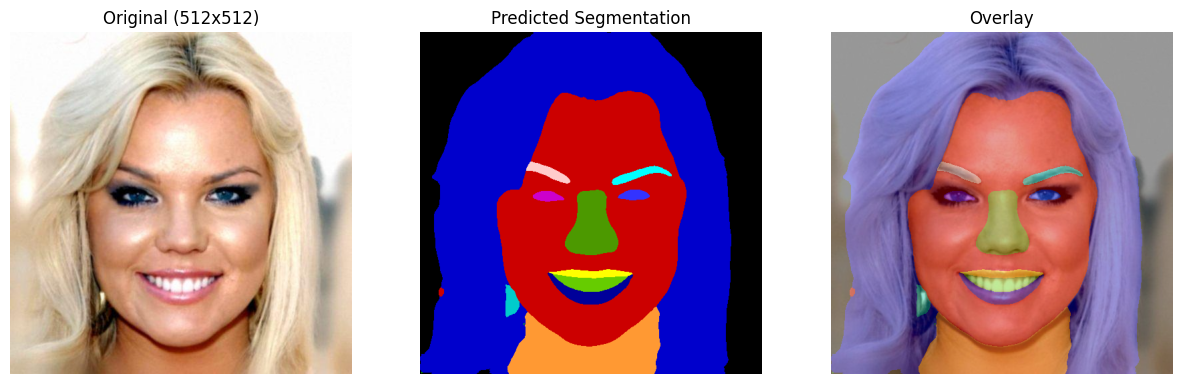

In [18]:
# The code block's aim is to test for a single image and visualize the output

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_palette():
    # Standard colors for CelebAMask-HQ 19 classes
    return [
        [0, 0, 0], [204, 0, 0], [76, 153, 0], [204, 204, 0], [51, 51, 255],
        [204, 0, 204], [0, 255, 255], [255, 204, 204], [102, 51, 0], [255, 0, 0],
        [102, 204, 0], [255, 255, 0], [0, 0, 153], [0, 0, 204], [255, 51, 153],
        [0, 204, 204], [0, 51, 0], [255, 153, 51], [0, 204, 0]
    ]

def test_transform_img(resize, totensor, normalize, centercrop, colorjitter):
    options = []
    if totensor:
        options.append(transforms.ToTensor())
    if normalize:
        options.append(transforms.Normalize(mean=[0.5081, 0.4134, 0.3607],std=[0.3013, 0.2757, 0.2692]))
    transform = transforms.Compose(options)
    return transform

def visualize_prediction(model_path, img_path):
    # Backend
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, _ = build_model(device) 
    
    # Weights loading
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    # Image Pre Processing
    transform = test_transform_img(True, True, True, False, False)
    
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # Map to Colors
    palette = get_palette()
    color_mask = np.zeros((512, 512, 3), dtype=np.uint8)
    for cls in range(19):
        color_mask[pred_mask == cls] = palette[cls]

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original (512x512)")
    plt.imshow(img_pil.resize((512, 512)))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Predicted Segmentation")
    plt.imshow(color_mask)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(img_pil.resize((512, 512)))
    plt.imshow(color_mask, alpha=0.4)
    plt.axis('off')

    plt.show()

visualize_prediction(
    model_path='/kaggle/working/checkpoints/model_best_epoch_245.pth',
    img_path='/kaggle/input/datasets/sriharisridhar123/celeb-subset/train/images/d53edb3601e5413a81c5962e19a6ab6e.jpg'
)

In [19]:
# Code to generate test output images with test set inputs

import os
import torch
import numpy as np
from PIL import Image
from glob import glob

def get_palette():
    return [
        [0, 0, 0], [204, 0, 0], [76, 153, 0], [204, 204, 0], [51, 51, 255],
        [204, 0, 204], [0, 255, 255], [255, 204, 204], [102, 51, 0], [255, 0, 0],
        [102, 204, 0], [255, 255, 0], [0, 0, 153], [0, 0, 204], [255, 51, 153],
        [0, 204, 204], [0, 51, 0], [255, 153, 51], [0, 204, 0]
    ]

def test_transform_img(resize, totensor, normalize, centercrop, colorjitter):
    options = []
    if totensor:
        options.append(transforms.ToTensor())
    if normalize:
        options.append(transforms.Normalize(mean=[0.5081, 0.4134, 0.3607],std=[0.3013, 0.2757, 0.2692]))
    transform = transforms.Compose(options)
    return transform

def get_segmentation(mask):
    
    mask = mask.cpu().numpy().astype(np.uint8)

    mask_img = Image.fromarray(mask, mode="P")

    palette = get_palette()

    flat_palette = [c for color in palette for c in color]
    flat_palette += [0] * (768 - len(flat_palette))

    mask_img.putpalette(flat_palette)

    return mask_img


def generate_labels(model_path, image_folder, output_folder, num_images=100):

    os.makedirs(output_folder, exist_ok=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model, _ = build_model(device)

    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    transform = test_transform_img(True, True, True, False, False)

    image_paths = sorted(glob(os.path.join(image_folder, "*.jpg")))[:num_images]

    for img_path in image_paths:

        img_pil = Image.open(img_path).convert("RGB")
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            pred_mask = torch.argmax(output, dim=1).squeeze(0)

        mask_img = get_segmentation(pred_mask)

        filename = os.path.basename(img_path).replace(".jpg", ".png")
        save_path = os.path.join(output_folder, filename)

        mask_img.save(save_path)

        print("Saved:", save_path)

generate_labels(
    model_path="/kaggle/working/checkpoints/model_best_epoch_245.pth",
    image_folder="/kaggle/input/datasets/sriharisridhar123/test-faces/test/images",
    output_folder="/kaggle/working/predicted_test_labels_newer",
    num_images=100
)

Total Trainable Params: 1,813,795
Safe: Under the 1,821,085 limit.
Saved: /kaggle/working/predicted_test_labels_newer/02ca91df175b4db587759ddd25ca7957.png
Saved: /kaggle/working/predicted_test_labels_newer/082cfddedd3141c98b60e4a501626722.png
Saved: /kaggle/working/predicted_test_labels_newer/0ee42dbb79124fe1a73046a134e02bbf.png


/tmp/ipykernel_55/121548830.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_img = Image.fromarray(mask, mode="P")


Saved: /kaggle/working/predicted_test_labels_newer/106c888e668e491aa74ff3078a5a6266.png
Saved: /kaggle/working/predicted_test_labels_newer/1316dd1221f540128823a205a39324a3.png
Saved: /kaggle/working/predicted_test_labels_newer/17684203dbc04dcbb91cce2f3e24ae5d.png
Saved: /kaggle/working/predicted_test_labels_newer/18f63b3205924aa8956b816e493c7ca0.png
Saved: /kaggle/working/predicted_test_labels_newer/1907cad3d8ed4025ac62a874e3674cb4.png
Saved: /kaggle/working/predicted_test_labels_newer/1ca61dec3d25413e8ac95b7ef604b7c3.png
Saved: /kaggle/working/predicted_test_labels_newer/1e9f8e51f5094272a8d60134606149ce.png
Saved: /kaggle/working/predicted_test_labels_newer/20f5aa71187048f48a28a5ba34fbdf56.png
Saved: /kaggle/working/predicted_test_labels_newer/214b1d88f27344f8a241f68681c3fee5.png
Saved: /kaggle/working/predicted_test_labels_newer/21bf027ce0924a408d860306ffcc8116.png
Saved: /kaggle/working/predicted_test_labels_newer/21fbdff0b064424d83599293496d4724.png
Saved: /kaggle/working/predicted

In [23]:
import cv2
import numpy as np
import os

def calculate_dataset_stats_for_norm(img_folder):
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0

    img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    print(f"Processing {len(img_files)} images...")

    for filename in img_files:
        img_path = os.path.join(img_folder, filename)
        
        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float64) / 255.0

        channel_sum += np.sum(img, axis=(0, 1))
        channel_sq_sum += np.sum(np.square(img), axis=(0, 1))
        
        pixel_count += img.shape[0] * img.shape[1]

    mean = channel_sum / pixel_count
    
    var = (channel_sq_sum / pixel_count) - (mean ** 2)
    std = np.sqrt(var)

    return mean, std

folder_path = "/kaggle/input/datasets/sriharisridhar123/celeb-subset/train/images/"
mean, std = calculate_dataset_stats_for_norm(folder_path)

print(f"Mean (RGB): {mean}")
print(f"Std (RGB):  {std}")

Processing 1000 images...
Mean (RGB): [0.50810071 0.41338848 0.36066988]
Std (RGB):  [0.3012641  0.27571241 0.26924012]


In [20]:
!zip -r data_augmentation_updated_flip_removed_test.zip /kaggle/working/predicted_test_labels_newer

  adding: kaggle/working/predicted_test_labels_newer/ (stored 0%)
  adding: kaggle/working/predicted_test_labels_newer/1ca61dec3d25413e8ac95b7ef604b7c3.png (deflated 16%)
  adding: kaggle/working/predicted_test_labels_newer/2af6646c3c364354838e31e2e3d72d25.png (deflated 11%)
  adding: kaggle/working/predicted_test_labels_newer/739a8dfc7c614b34a52f969ce66f4904.png (deflated 15%)
  adding: kaggle/working/predicted_test_labels_newer/41ff2c9aefa54be4848d0face82bc1ab.png (deflated 15%)
  adding: kaggle/working/predicted_test_labels_newer/d721b16552094fffba085f74357c9dbf.png (deflated 15%)
  adding: kaggle/working/predicted_test_labels_newer/461c4993c50e4ac59cbdcd14a6ef5725.png (deflated 21%)
  adding: kaggle/working/predicted_test_labels_newer/3045681a07fd49379bfbbed2a47f9145.png (deflated 17%)
  adding: kaggle/working/predicted_test_labels_newer/dcfe5e838ffc4db9b84c78f90e114b99.png (deflated 18%)
  adding: kaggle/working/predicted_test_labels_newer/9bc56fc66192477b91f51fa732de7b6a.png (def

In [22]:
!zip -r checkpoints_unet_test.zip /kaggle/working/checkpoints

  adding: kaggle/working/checkpoints/ (stored 0%)
  adding: kaggle/working/checkpoints/model_best_epoch_50.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_172.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_84.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_147.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_48.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_epoch_215.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_40.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_59.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_161.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_60.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_best_epoch_193.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_epoch_50.pth (deflated 8%)
  adding: kaggle/working/checkpoints/model_epoch_235.pt